# Phase 2 - Label construction
Neither target exists in the data. We derive them from the route-leg actuals, and **correct label construction is assessed**, so every choice below is tested against the data and written down.

| Target | Definition | Why |
|---|---|---|
| `service_min` | `leave_outlet_time - max(arrival_time, window_open_time)` | Goods are received only inside the window. A vehicle that arrives early waits until it opens; the wait is not handling time. |
| `late` | `arrival_time > window_close_time` | Lateness = arriving *after the window closes* (booklet). Early arrival and in-window arrival are on time. |

Input: `data/interim/train_joined.pkl` from Phase 1 (dispatched orders joined to their route leg). Output: `train_labeled.pkl`, `test_features_base.pkl`.

In [1]:
import sys; sys.path.append("../../tools")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from task1_common import *
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
t = load_task1_tables()

## 1. Load the audited train table

In [2]:
tr = pd.read_pickle(INTERIM / 'train_joined.pkl')
te = pd.read_pickle(INTERIM / 'test_joined.pkl')
print(tr.shape, te.shape)
tr[['delivery_id', 'brand', 'arrival_time', 'window_open_time', 'window_close_time', 'leave_outlet_time']].head()

(91894, 56) (5014, 41)


,delivery_id,brand,arrival_time,window_open_time,window_close_time,leave_outlet_time
0,ORD0000085,Fresh,04:48,05:00,07:30,05:12
1,ORD0000089,Fresh,05:21,04:00,07:45,05:29
2,ORD0000087,Fresh,05:39,03:00,08:00,05:47
3,ORD0000093,Fresh,05:55,03:00,08:00,06:01
4,ORD0000122,Fresh,06:26,03:00,08:00,06:32


## 2. Build the labels
The logic lives in `tools/task1_common.make_labels` so the final notebook and the audit use the identical definition.

In [3]:
lab = make_labels(tr)
tr = tr.join(lab)
print(lab.describe().round(2))
print('\nlate rate:', tr.late.mean().round(4), '| early arrivals (wait>0):', (tr.wait_min > 0).mean().round(4))

       service_min     late  wait_min
count      91894.0  91894.0   91894.0
mean          19.0      0.2      0.88
std          14.91      0.4      5.74
min            2.0      0.0       0.0
25%           11.0      0.0       0.0
50%           15.0      0.0       0.0
75%           22.0      0.0       0.0
max          428.0      1.0     132.0

late rate: 0.1958 | early arrivals (wait>0): 0.0438


## 3. Why the wait must be excluded
For vehicles that arrive early, the raw stay (`leave - arrival`) contains the wait. A naive label would be inflated for those rows.

In [10]:
f = tr[(tr.brand == 'Fresh') & (tr.dock_type == 'rear_dock')]
print('Fresh / rear_dock median minutes by early arrival:')
print(f.groupby(f.wait_min > 0)[['stay_min', 'service_min', 'wait_min']].median().round(1).rename(index={False: 'on time / late', True: 'early (waited)'}))
e = f[f.wait_min > 0]
print(f'\ncorr(raw stay, wait) for early arrivals : {e.stay_min.corr(e.wait_min):.3f}  <- raw stay is mostly the wait')
print(f'corr(service_min, wait) for early arrivals: {e.service_min.corr(e.wait_min):.3f}  <- corrected label is independent of it')
naive_err = (tr.stay_min - tr.service_min)
print(f'\nnaive label would overstate service time on {(naive_err > 0).mean():.1%} of rows by {naive_err[naive_err > 0].mean():.1f} min on average')

Fresh / rear_dock median minutes by early arrival:
                stay_min  service_min  wait_min
wait_min                                       
on time / late      15.0         15.0       0.0
early (waited)      28.0         12.0      13.0

corr(raw stay, wait) for early arrivals : 0.917  <- raw stay is mostly the wait
corr(service_min, wait) for early arrivals: -0.160  <- corrected label is independent of it

naive label would overstate service time on 4.4% of rows by 20.0 min on average


## 4. Validate `service_min`
Sanity: strictly positive, sensible scale, close to the dispatcher allowance in the typical case, and no hidden structure in the tail.

non-positive: 0 | min/max: 2 428 | NaN: 0

service_min by brand:
         count  mean   std  min   50%    90%    99%    max
brand                                                     
Fresh  87457.0  17.1  10.1  2.0  15.0   29.0   54.0  201.0
Style   2733.0  52.6  31.2  8.0  46.0   89.0  167.7  301.0
Tech    1704.0  60.6  38.9  7.0  52.0  108.0  195.0  428.0

median service_min vs allowance (brand x dock):
                 median  mean  allowance      n
brand dock_type                                
Fresh rear_dock    15.0  16.9         15  60107
      street       14.0  17.6         16  27350
Style mall_bay     61.0  67.3         59    983
      rear_dock    30.0  34.7         38    652
      street       45.0  49.9         46   1098
Tech  mall_bay     74.0  87.8         55    284
      rear_dock    35.0  40.6         43    809
      street       67.0  74.4         55    611

mean service_min, single- vs multi-stop routes, by brand (Style/Tech are mostly single-stop):
                

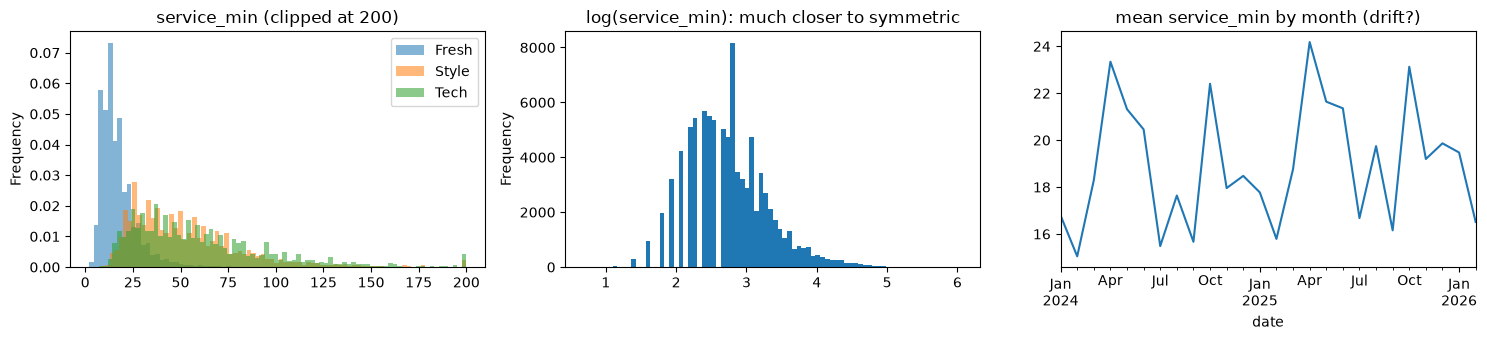

skew raw / log: 4.63 / 0.61


In [5]:
s = tr.service_min
print('non-positive:', (s <= 0).sum(), '| min/max:', s.min(), s.max(), '| NaN:', s.isna().sum())
print('\nservice_min by brand:'); print(tr.groupby('brand').service_min.describe(percentiles=[.5, .9, .99]).round(1))
print('\nmedian service_min vs allowance (brand x dock):')
cmp = tr.groupby(['brand', 'dock_type']).agg(median=('service_min', 'median'), mean=('service_min', 'mean'), allowance=('service_allowance_min', 'first'), n=('service_min', 'size')).round(1)
print(cmp)
single = (tr.groupby('route_id').seq.transform('max') == 0).rename('single_stop_route')
print('\nmean service_min, single- vs multi-stop routes, by brand (Style/Tech are mostly single-stop):')
print(tr.groupby(['brand', single]).service_min.agg(['mean', 'count']).round(1))

fig, ax = plt.subplots(1, 3, figsize=(15, 3.5))
for b, g in tr.groupby('brand'): g.service_min.clip(0, 200).plot.hist(bins=80, alpha=.55, label=b, ax=ax[0], density=True)
ax[0].legend(); ax[0].set_title('service_min (clipped at 200)')
np.log(tr.service_min).plot.hist(bins=80, ax=ax[1]); ax[1].set_title('log(service_min): much closer to symmetric')
tr.groupby(tr.date.dt.to_period('M')).service_min.mean().plot(ax=ax[2]); ax[2].set_title('mean service_min by month (drift?)')
plt.tight_layout(); plt.show()
print('skew raw / log:', s.skew().round(2), '/', np.log(s).skew().round(2))

## 5. The long tail: keep or drop?
Stays beyond 240 min are rare. Decide from evidence: are they isolated errors or the heavy tail of Style/Tech deliveries (large heavy items, mall bays)?

In [11]:
tail = tr[tr.service_min > 150]
print('rows >150 min:', len(tail), f'({len(tail)/len(tr):.3%})', '| by brand:', tail.brand.value_counts().to_dict())
print('rows >240 min:', (tr.service_min > 240).sum())
print('\nweight / volume of tail rows vs the same brand overall (medians):')
print(pd.concat([tail.groupby('brand')[['order_weight_kg', 'order_volume_m3']].median(),
                 tr.groupby('brand')[['order_weight_kg', 'order_volume_m3']].median()], axis=1, keys=['tail', 'all']).round(2))
# is the tail explained by order size? compare tail to the size-matched expectation within brand+dock
q = tr.groupby(['brand', 'dock_type']).service_min.quantile(.99).rename('p99').reset_index()
chk = tr.merge(q, on=['brand', 'dock_type'])
print('\nshare of each brand+dock above its own p99 (should be ~1% if the tail is just the distribution):')
print((chk.service_min > chk.p99).groupby([chk.brand, chk.dock_type]).mean().round(4))

rows >150 min: 89 (0.097%) | by brand: {'Tech': 44, 'Style': 36, 'Fresh': 9}
rows >240 min: 13

weight / volume of tail rows vs the same brand overall (medians):
                 tail                             all                
      order_weight_kg order_volume_m3 order_weight_kg order_volume_m3
brand                                                                
Fresh         1101.50            5.55           310.9            1.68
Style          902.85           14.08           517.8            8.36
Tech          2270.95            7.57           827.0            2.77

share of each brand+dock above its own p99 (should be ~1% if the tail is just the distribution):
brand  dock_type
Fresh  rear_dock    0.0094
       street       0.0095
Style  mall_bay     0.0102
       rear_dock    0.0107
       street         0.01
Tech   mall_bay     0.0106
       rear_dock    0.0111
       street       0.0115
dtype: Float64


## 6. Validate `late`
Rate by brand, mall/dock, month, and planned slack. The relationship with planned slack should be monotonic - that is the main structure the model will learn.

late rate by brand:
         mean    sum  count
brand                      
Fresh  0.2035  17799  87457
Style  0.0549    150   2733
Tech   0.0246     42   1704

late rate by dock_type / parking_constraint:
                                mean  count
dock_type parking_constraint               
mall_bay  mall_dock           0.1137   1267
rear_dock normal              0.2234  61568
street    normal              0.1857  16781
          van_only            0.0794  12278

late rate by planned slack (window_close - planned_arrival, min):
             mean  count
slack_band              
(-999, 0]   0.983    653
(0, 15]     0.923   1743
(15, 30]    0.794   3078
(30, 45]    0.628   4720
(45, 60]    0.455   6426
(60, 90]    0.252  15092
(90, 120]   0.105  18854
(120, 180]  0.046  32407
(180, 999]  0.015   8921

boundary sensitivity: arrival == close in 0.003 of rows; rate with > : 0.1958 | with >= : 0.1988
rows within +-1 min of the close (rounding noise on the label): 0.0088


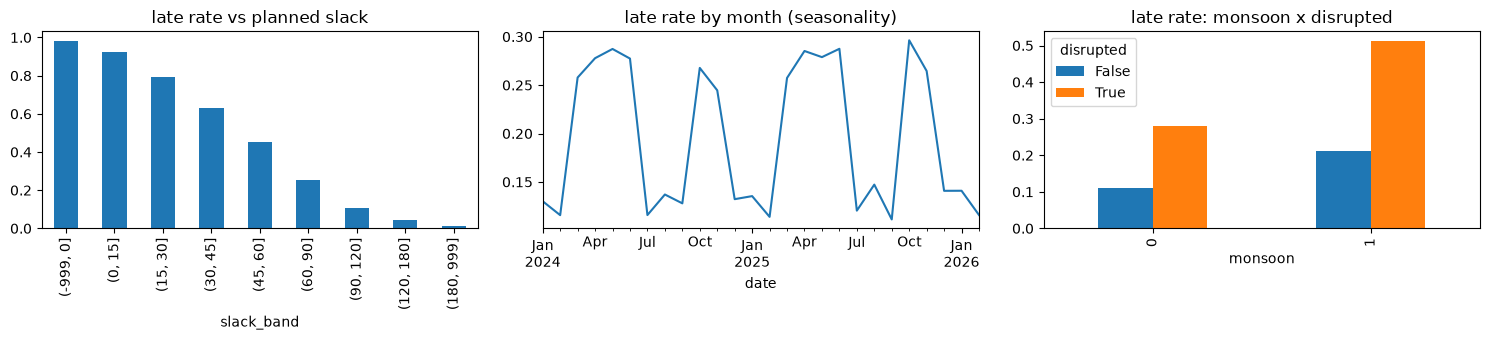

In [12]:
print('late rate by brand:'); print(tr.groupby('brand').late.agg(['mean', 'sum', 'count']).round(4))
print('\nlate rate by dock_type / parking_constraint:'); print(tr.groupby(['dock_type', 'parking_constraint']).late.agg(['mean', 'count']).round(4))
tr['slack_planned'] = tr.window_close_time_m - tr.planned_arrival_time_m
bins = [-999, 0, 15, 30, 45, 60, 90, 120, 180, 999]
tr['slack_band'] = pd.cut(tr.slack_planned, bins)
sl = tr.groupby('slack_band', observed=True).late.agg(['mean', 'count']).round(3)
print('\nlate rate by planned slack (window_close - planned_arrival, min):'); print(sl)

print('\nboundary sensitivity: arrival == close in', (tr.arrival_time_m == tr.window_close_time_m).mean().round(4), 'of rows;',
      'rate with > :', (tr.arrival_time_m > tr.window_close_time_m).mean().round(4), '| with >= :', (tr.arrival_time_m >= tr.window_close_time_m).mean().round(4))
print('rows within +-1 min of the close (rounding noise on the label):', ((tr.arrival_time_m - tr.window_close_time_m).abs() <= 1).mean().round(4))

fig, ax = plt.subplots(1, 3, figsize=(15, 3.5))
sl['mean'].plot.bar(ax=ax[0]); ax[0].set_title('late rate vs planned slack')
tr.groupby(tr.date.dt.to_period('M')).late.mean().plot(ax=ax[1]); ax[1].set_title('late rate by month (seasonality)')
tr.groupby(['monsoon', tr.disruption_index.le(80).rename('disrupted')]).late.mean().unstack().plot.bar(ax=ax[2]); ax[2].set_title('late rate: monsoon x disrupted')
plt.tight_layout(); plt.show()

## 7. Base rates for calibration later
The test window is Feb-Mar. Overall base rates mislead; the same season in earlier years is the relevant reference.

In [8]:
season = tr[tr.date.dt.month.isin([2, 3])]
print('late rate, all months:', tr.late.mean().round(4), '| Feb-Mar only:', season.late.mean().round(4))
print(season.groupby(season.date.dt.year).late.agg(['mean', 'count']).round(4))
print('\nFeb-Mar by monsoon flag:'); print(season.groupby('monsoon').late.agg(['mean', 'count']).round(4))
print('\ntest monsoon share:', te.monsoon.mean().round(3), '| train Feb-Mar monsoon share:', season.monsoon.mean().round(3))

late rate, all months: 0.1958 | Feb-Mar only: 0.1803
        mean  count
date               
2024  0.1882   7143
2025  0.1880   6948
2026  0.1158   1692

Feb-Mar by monsoon flag:
           mean  count
monsoon               
0        0.1150   8555
1        0.2576   7228

test monsoon share: 0.665 | train Feb-Mar monsoon share: 0.458


## 8. Leakage guard and save
A column may be a model input only if it exists in the test table. Everything that exists only in train (actual times, delays, travel ratio, stay, wait) goes to a separate diagnostics table.

In [9]:
test_cols = set(te.columns)
safe_cols = [c for c in tr.columns if c in test_cols]
label_cols = ['service_min', 'late']
# reference columns merged during the audit: legitimate at prediction time, re-joined for train AND test in Phase 3
reference_cols = ['dock_type', 'parking_constraint', 'service_allowance_min', 'disruption_index']
scratch_cols = ['slack_planned', 'slack_band']
actual_only = [c for c in tr.columns if c not in test_cols and c not in label_cols + reference_cols + scratch_cols]
print('safe (also in test):', len(safe_cols))
print('reference (dropped here, re-joined in Phase 3 for both tables):', reference_cols)
print('ACTUAL-TIME / train-only, never features:', actual_only)

# actual-time columns that are in both tables by name (arrival/leave/depart are null/absent in test, so they must not be features)
absent_in_test = [c for c in ['actual_depart_time', 'actual_travel_duration_min', 'arrival_time', 'leave_outlet_time',
                              'actual_depart_time_m', 'arrival_time_m', 'leave_outlet_time_m'] if c in te.columns]
print('actual-time columns present in test table (should be empty):', absent_in_test)

assert tr.service_min.gt(0).all() and tr.late.isin([0, 1]).all() and tr.service_min.notna().all()
assert tr.delivery_id.is_unique and te.delivery_id.is_unique

train_labeled = tr[safe_cols + label_cols].copy()
actuals = tr[['delivery_id'] + actual_only].copy()
train_labeled.to_pickle(INTERIM / 'train_labeled.pkl'); actuals.to_pickle(INTERIM / 'train_actuals_diagnostic.pkl'); te.to_pickle(INTERIM / 'test_features_base.pkl')
print('\nsaved train_labeled', train_labeled.shape, '| actuals', actuals.shape, '| test_features_base', te.shape)

safe (also in test): 41
reference (dropped here, re-joined in Phase 3 for both tables): ['dock_type', 'parking_constraint', 'service_allowance_min', 'disruption_index']
ACTUAL-TIME / train-only, never features: ['actual_depart_time', 'actual_travel_duration_min', 'arrival_time', 'leave_outlet_time', 'actual_depart_time_m', 'arrival_time_m', 'leave_outlet_time_m', 'delay_min', 'depart_delay_min', 'travel_ratio', 'stay_min', 'wait_min']
actual-time columns present in test table (should be empty): []

saved train_labeled (91894, 43) | actuals (91894, 13) | test_features_base (5014, 41)


### Label decisions (feeds the preprocessing document)
| # | Decision | Evidence |
|---|---|---|
| 1 | `service_min = leave - max(arrival, window_open)` | For early arrivals raw stay correlates ~0.9 with the wait; the corrected label removes it. |
| 2 | `late = arrival > window_close` (strict) | Booklet definition. `>=` changes the rate by only 0.3 pt, so the choice is not material. |
| 3 | Keep the long service-time tail | Concentrated in Style/Tech and large orders, not isolated errors. Handle with a log target and robust metrics. |
| 4 | Model `log(service_min)` | Raw skew is high; log is near symmetric. Evaluate in minutes. |
| 5 | Calibrate late probabilities with season/monsoon in mind | Feb-Mar late rate is 11.5% without monsoon vs 25.8% with it; test is 66% monsoon legs, so its expected base rate is ~21%, not the 19.6% overall. |
| 6 | Train-only columns excluded from features | Enforced by the test-column rule in section 8. |
